# Proyecto: Procesamiento de Datos
## Pontificia Universidad Javeriana — Facultad de Ingeniería
### Departamento de Ingeniería de Sistemas | Procesamiento de Alto Volumen de Datos
**Profesor:** John Corredor, PhD

**Integrantes:**
- Ian Tomás Felipe Fonseca Coronado
- Andrés Raba
- Jorge Esteban Gómez Zuluaga
- Daniel Galvis

**Entrega 2 — Sección 1: Filtros, Limpieza y Transformaciones**

---
> **Municipios de análisis:** Bello, Itagüí y Envigado (Antioquia)  
> **Datasets:** Internet Fijo 2021 | Internet Fijo 2022–2023 | Saber 11 (Clasif_planteles)  
> **Herramienta:** Apache Spark (PySpark) sobre clúster de Alto Rendimiento


## 1. Configuración del entorno y creación de la sesión Spark

In [1]:
#!pip install pyspark

In [1]:
import os
import sys
import glob

# Limpiar variables conflictivas
os.environ.pop("JAVA_TOOL_OPTIONS", None)
os.environ["SPARK_HOME"] = "/Almacen/Spark"

# Usar el PySpark del clúster, no el de pip
sys.path.insert(0, "/Almacen/Spark/python")
py4j_zip = glob.glob("/Almacen/Spark/python/lib/py4j-*.zip")
if py4j_zip:
    sys.path.insert(0, py4j_zip[0])

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import upper, translate, trim
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

spark = (SparkSession.builder
    .appName("Procesamiento_Datos_Entrega2")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "4")
    .master("local[*]")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
print(f"Sesion Spark lista — version: {spark.version}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/23 12:20:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion Spark lista — version: 3.5.8


---
## 2. Carga de datos en el clúster Spark

Se cargan los tres datasets desde el sistema de archivos del clúster.
Los archivos CSV de internet se leen con opciones de codificación UTF-8.
El archivo Excel de Saber 11 se lee con Pandas y se convierte a Spark DataFrame.


In [2]:
import subprocess
r = subprocess.run(
    ["find", "/", "-name", "*Internet*Fijo*", "-o", "-name", "*saber*11*"],
    capture_output=True, text=True, timeout=15
)
print(r.stdout)

/Almacen/.ipynb_checkpoints/Internet_Fijo_Accesos_por_tecnología_y_segmento_2021-checkpoint.csv
/Almacen/.Trash-1001/info/Cuadros_salida_saber_11_2023.xlsx.trashinfo
/Almacen/.Trash-1001/info/Cuadros_salida_saber_11_2023.csv.trashinfo
/Almacen/.Trash-1001/files/Cuadros_salida_saber_11_2023.xlsx
/Almacen/.Trash-1001/files/Cuadros_salida_saber_11_2023.csv
/Almacen/Proyecto/.ipynb_checkpoints/Internet_Fijo_Accesos_por_tecnología_y_segmento_2022_a_2023-checkpoint.csv
/Almacen/Proyecto/Internet_Fijo_Accesos_por_tecnología_y_segmento_2021.csv
/Almacen/Proyecto/Internet_Fijo_Accesos_por_tecnología_y_segmento_2022_a_2023.csv
/Almacen/Proyecto/Cuadros_salida_saber_11_2023.csv
/Almacen/Internet_Fijo_Accesos_por_tecnología_y_segmento_2021.csv
/Almacen/Internet_Fijo_Accesos_por_tecnología_y_segmento_2022_a_2023.csv
/Almacen/Cuadros_salida_saber_11_2023.xlsx
/Almacen/T4_indice_saber11.png



In [3]:
#!pip install openpyxl

In [4]:
RUTA_INTERNET_2021  = '/Almacen/Internet_Fijo_Accesos_por_tecnología_y_segmento_2021.csv'
RUTA_INTERNET_22_23 = '/Almacen/Internet_Fijo_Accesos_por_tecnología_y_segmento_2022_a_2023.csv'
RUTA_SABER11        = '/Almacen/Cuadros_salida_saber_11_2023.xlsx'  # ← el original

df_int_2021 = spark.read.csv(
    RUTA_INTERNET_2021, header=True, inferSchema=True, encoding='UTF-8', sep=','
)
df_int_2223 = spark.read.csv(
    RUTA_INTERNET_22_23, header=True, inferSchema=True, encoding='UTF-8', sep=','
)

pdf_saber11 = pd.read_excel(
    RUTA_SABER11,
    sheet_name='Clasif_planteles',
    header=7,
    engine='openpyxl'
)

# Convertir absolutamente todas las columnas a string
# Esto evita cualquier conflicto de tipos con Spark
pdf_saber11 = pdf_saber11.astype(str)

# Limpiar valores "nan" que quedan como texto
pdf_saber11 = pdf_saber11.replace('nan', None)

df_saber11 = spark.createDataFrame(pdf_saber11)

print(f'Internet 2021:     {df_int_2021.count():,} filas | {len(df_int_2021.columns)} columnas')
print(f'Internet 2022-23:  {df_int_2223.count():,} filas | {len(df_int_2223.columns)} columnas')
print(f'Saber 11:          {df_saber11.count():,} filas  | {len(df_saber11.columns)} columnas')

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [5]:
df_int_2021.printSchema()
df_int_2021.show(3, truncate=False)


root
 |-- AÑO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- PROVEEDOR: string (nullable = true)
 |-- COD_DEPARTAMENTO: integer (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- COD_MUNICIPIO: integer (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- SEGMENTO: string (nullable = true)
 |-- TECNOLOGIA: string (nullable = true)
 |-- VELOCIDAD_BAJADA: string (nullable = true)
 |-- VELOCIDAD_SUBIDA: string (nullable = true)
 |-- No DE ACCESOS: integer (nullable = true)

+----+---------+---------------------------------------+----------------+---------------+-------------+------------+-----------------------+---------------------------------------+----------------+----------------+-------------+
|AÑO |TRIMESTRE|PROVEEDOR                              |COD_DEPARTAMENTO|DEPARTAMENTO   |COD_MUNICIPIO|MUNICIPIO   |SEGMENTO               |TECNOLOGIA                             |VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|No DE ACCESOS|
+----+-------

In [6]:
df_int_2223.printSchema()
df_int_2223.show(3, truncate=False)


root
 |-- AÑO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- PROVEEDOR: string (nullable = true)
 |-- COD_DEPARTAMENTO: integer (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- COD_MUNICIPIO: integer (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- SEGMENTO: string (nullable = true)
 |-- TECNOLOGIA: string (nullable = true)
 |-- VELOCIDAD_BAJADA: string (nullable = true)
 |-- VELOCIDAD_SUBIDA: string (nullable = true)
 |-- No DE ACCESOS: integer (nullable = true)

+----+---------+-----------------------------------+----------------+------------+-------------+----------------+-----------------------+------------------------------+----------------+----------------+-------------+
|AÑO |TRIMESTRE|PROVEEDOR                          |COD_DEPARTAMENTO|DEPARTAMENTO|COD_MUNICIPIO|MUNICIPIO       |SEGMENTO               |TECNOLOGIA                    |VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|No DE ACCESOS|
+----+---------+---------------------

In [7]:
df_saber11.printSchema()
df_saber11.show(3, truncate=False)


NameError: name 'df_saber11' is not defined

---
## 3. Filtros aplicados

| # | Filtro | Justificacion |
|---|--------|---------------|
| 1 | Seleccion por municipio (Bello, Itagui, Envigado) | Reduce el alcance al universo definido en Entrega 1. Se excluye Medellin porque su volumen es desproporcionado y genera sesgo en el analisis. |
| 2 | Eliminacion de columnas Unnamed (Saber 11) | No contienen informacion analitica y afectan la limpieza del esquema. |


In [8]:
# Funcion para normalizar nombres de municipio (MAYUSCULAS, sin tilde)
def normalizar_municipio(col_name):
    return upper(trim(translate(
        col_name,
        'áéíóúÁÉÍÓÚäëïöüÄËÏÖÜàèìòùÀÈÌÒÙ',
        'AEIOUAEIOUAEIOUAEIOUAEIOUAEIOU'
    )))

MUNICIPIOS_OBJETIVO = ['BELLO', 'ITAGUI', 'ENVIGADO']
print('Municipios objetivo:', MUNICIPIOS_OBJETIVO)


Municipios objetivo: ['BELLO', 'ITAGUI', 'ENVIGADO']


In [9]:
# --- Filtro 1A: Internet 2021 ---
df_int_2021_f = (
    df_int_2021
    .withColumn('MUN_N', normalizar_municipio(F.col('MUNICIPIO')))
    .withColumn('DEP_N', normalizar_municipio(F.col('DEPARTAMENTO')))
    .filter((F.col('DEP_N') == 'ANTIOQUIA') & (F.col('MUN_N').isin(MUNICIPIOS_OBJETIVO)))
    .drop('MUN_N', 'DEP_N')
)
n0 = df_int_2021.count()
n1 = df_int_2021_f.count()
print(f'Internet 2021 -> antes: {n0:,} | despues: {n1:,} | reduccion: {100*(1-n1/n0):.1f}%')
df_int_2021_f.show(5, truncate=False)


Internet 2021 -> antes: 399,848 | despues: 6,722 | reduccion: 98.3%
+----+---------+-----------------------------------+----------------+------------+-------------+---------+-----------------------+---------------------------------------+----------------+----------------+-------------+
|AÑO |TRIMESTRE|PROVEEDOR                          |COD_DEPARTAMENTO|DEPARTAMENTO|COD_MUNICIPIO|MUNICIPIO|SEGMENTO               |TECNOLOGIA                             |VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|No DE ACCESOS|
+----+---------+-----------------------------------+----------------+------------+-------------+---------+-----------------------+---------------------------------------+----------------+----------------+-------------+
|2021|4        |COMUNICACION CELULAR S A COMCEL S A|5               |ANTIOQUIA   |5266         |ENVIGADO |RESIDENCIAL - ESTRATO 4|CABLE                                  |400,00          |10,00           |11           |
|2021|2        |UNE EPM TELECOMUNICACIONES S.A.    |5   

In [10]:
# --- Filtro 1B: Internet 2022-2023 ---
df_int_2223_f = (
    df_int_2223
    .withColumn('MUN_N', normalizar_municipio(F.col('MUNICIPIO')))
    .withColumn('DEP_N', normalizar_municipio(F.col('DEPARTAMENTO')))
    .filter((F.col('DEP_N') == 'ANTIOQUIA') & (F.col('MUN_N').isin(MUNICIPIOS_OBJETIVO)))
    .drop('MUN_N', 'DEP_N')
)
n0 = df_int_2223.count()
n1 = df_int_2223_f.count()
print(f'Internet 2022-23 -> antes: {n0:,} | despues: {n1:,} | reduccion: {100*(1-n1/n0):.1f}%')
df_int_2223_f.show(5, truncate=False)


Internet 2022-23 -> antes: 1,369,085 | despues: 35,867 | reduccion: 97.4%
+----+---------+-----------------------------------+----------------+------------+-------------+---------+-----------------------+---------------------------------------+----------------+----------------+-------------+
|AÑO |TRIMESTRE|PROVEEDOR                          |COD_DEPARTAMENTO|DEPARTAMENTO|COD_MUNICIPIO|MUNICIPIO|SEGMENTO               |TECNOLOGIA                             |VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|No DE ACCESOS|
+----+---------+-----------------------------------+----------------+------------+-------------+---------+-----------------------+---------------------------------------+----------------+----------------+-------------+
|2022|2        |UNE EPM TELECOMUNICACIONES S.A.    |5               |ANTIOQUIA   |5088         |BELLO    |RESIDENCIAL - ESTRATO 2|HYBRID FIBER COAXIAL (HFC)             |25,00           |5,00            |10           |
|2022|4        |UNE EPM TELECOMUNICACIONES S.A.   

In [11]:
# --- Filtro 1C: Saber 11 — filtro directo con todas las variantes ---
VARIANTES_MUNICIPIOS = [
    'BELLO', 'Bello',
    'ITAGÜÍ', 'Itagüí', 'ITAGUI', 'Itagui',
    'ENVIGADO', 'Envigado'
]

df_saber11_f = (
    df_saber11
    .filter(F.col('MUNICIPIO').isin(VARIANTES_MUNICIPIOS))
    .withColumn('MUNICIPIO', F.upper(F.col('MUNICIPIO')))
    .withColumn('MUNICIPIO', F.regexp_replace(F.col('MUNICIPIO'), 'Ü', 'U'))
    .withColumn('MUNICIPIO', F.regexp_replace(F.col('MUNICIPIO'), 'Í', 'I'))
    .withColumn('MUNICIPIO', F.regexp_replace(F.col('MUNICIPIO'), 'É', 'E'))
)

n1 = df_saber11_f.count()
print(f'Saber 11 filtrado: {n1} filas')
print('Municipios encontrados:')
df_saber11_f.select('MUNICIPIO').distinct().show()


NameError: name 'df_saber11' is not defined

In [ ]:
# --- Filtro 2: Eliminar columnas Unnamed (Saber 11) ---
cols_unnamed = [c for c in df_saber11_f.columns if 'Unnamed' in c or c.strip() == '']
if cols_unnamed:
    print(f'Columnas Unnamed eliminadas ({len(cols_unnamed)}): {cols_unnamed}')
    df_saber11_f = df_saber11_f.drop(*cols_unnamed)
else:
    print('No se encontraron columnas Unnamed.')
print(f'Columnas finales Saber 11: {df_saber11_f.columns}')


---
## 4. Limpieza de datos


In [ ]:
# --- 4.1 Reporte de valores faltantes ---
def reporte_nulos(df, nombre):
    print(f'\n=== {nombre} ===')
    total = df.count()
    hay_nulos = False
    for col_name in df.columns:
        n_nulos = df.filter(F.col(f'`{col_name}`').isNull()).count()
        if n_nulos > 0:
            hay_nulos = True
            print(f'  {col_name:<45} {n_nulos:>6} nulos ({100*n_nulos/total:.1f}%)')
    if not hay_nulos:
        print('  Sin valores faltantes relevantes.')

reporte_nulos(df_int_2021_f,  'Internet Fijo 2021')
reporte_nulos(df_int_2223_f,  'Internet Fijo 2022-2023')
reporte_nulos(df_saber11_f,   'Saber 11 (Clasif_planteles)')


In [12]:
# --- 4.2 Limpieza 1: Registros SC (Sin Clasificacion) en Saber 11 ---
# SC = planteles con menos de 10 evaluados, sin indice valido.
# Se crean dos versiones: con SC (cobertura) y sin SC (indices promedio).
n_sc = df_saber11_f.filter(F.col('CLASIFICACION') == 'SC').count()
print(f'Registros SC (sin clasificacion): {n_sc}')
df_saber11_clasif = df_saber11_f.filter(F.col('CLASIFICACION') != 'SC')
print(f'Saber 11 con clasificacion valida: {df_saber11_clasif.count()} filas')


NameError: name 'df_saber11_f' is not defined

In [13]:
# --- 4.3 Limpieza 2: Normalizar 'No DE ACCESOS' a tipo numerico ---
col_accesos = '`No DE ACCESOS`'
df_int_2021_f = df_int_2021_f.withColumn(
    'No DE ACCESOS',
    F.regexp_replace(F.col(col_accesos).cast('string'), ',', '').cast(DoubleType())
).filter(F.col('No DE ACCESOS') >= 0)

df_int_2223_f = df_int_2223_f.withColumn(
    'No DE ACCESOS',
    F.regexp_replace(F.col(col_accesos).cast('string'), ',', '').cast(DoubleType())
).filter(F.col('No DE ACCESOS') >= 0)

print('Accesos negativos o nulos eliminados.')
print(f'Internet 2021 limpio:     {df_int_2021_f.count():,} filas')
print(f'Internet 2022-23 limpio:  {df_int_2223_f.count():,} filas')


Accesos negativos o nulos eliminados.


Internet 2021 limpio:     6,722 filas


[Stage 23:======================================>                  (8 + 4) / 12]

Internet 2022-23 limpio:  35,867 filas


In [14]:
# --- 4.4 Limpieza 3: Estandarizar capitalizacion de MUNICIPIO ---
def estandarizar_mun(df):
    return df.withColumn('MUNICIPIO',
        translate(upper(F.col('MUNICIPIO')),
            'áéíóúÁÉÍÓÚ',
            'aeiouAEIOU')
    )

df_int_2021_f  = estandarizar_mun(df_int_2021_f)
df_int_2223_f  = estandarizar_mun(df_int_2223_f)
df_saber11_f   = estandarizar_mun(df_saber11_f)
df_saber11_clasif = estandarizar_mun(df_saber11_clasif)

print('Municipios estandarizados por dataset:')
for nombre, df in [('Internet 2021', df_int_2021_f),
                   ('Internet 2022-23', df_int_2223_f),
                   ('Saber 11', df_saber11_f)]:
    munis = sorted([r['MUNICIPIO'] for r in df.select('MUNICIPIO').distinct().collect()])
    print(f'  {nombre}: {munis}')


NameError: name 'df_saber11_f' is not defined

---
## 5. Transformaciones

| # | Transformacion | Justificacion |
|---|---------------|---------------|
| T1 | Consolidacion temporal (union 2021 + 2022-2023) | Genera un unico DataFrame con columna de periodo para analizar evolucion temporal |
| T2 | Accesos estandarizados por poblacion (accesos / 1.000 hab.) | Permite comparar penetracion de internet independientemente del tamano poblacional |
| T3 | Log10 de accesos | La variable de accesos tiene distribucion muy sesgada; Log10 normaliza su escala y mejora interpretabilidad en modelos |
| T4 | Puntaje promedio Saber 11 por municipio y periodo | Agrega datos de planteles al nivel municipio para cruzarlos con conectividad |


In [ ]:
# --- T1: Consolidacion temporal — union internet 2021 + 2022-2023 ---
df_internet_total = df_int_2021_f.union(df_int_2223_f)

print(f'Dataset internet consolidado (2021-2023): {df_internet_total.count():,} filas')
print('Distribucion por anio:')
df_internet_total.groupBy('AÑO').count().orderBy('AÑO').show()


In [ ]:
# --- T2: Accesos totales por municipio y anio ---
df_accesos_muni = (
    df_internet_total
    .groupBy('AÑO', 'MUNICIPIO')
    .agg(F.sum('No DE ACCESOS').alias('ACCESOS_TOTAL'))
    .orderBy('MUNICIPIO', 'AÑO')
)
print('Accesos totales por municipio y anio:')
df_accesos_muni.show(20, truncate=False)


In [ ]:
# --- T2: Estandarizacion por poblacion ---
# Fuente: proyecciones DANE 2023
poblacion = spark.createDataFrame([
    ('BELLO',    530000),
    ('ITAGUI',   290000),
    ('ENVIGADO', 250000),
], ['MUNICIPIO', 'POBLACION'])

df_accesos_std = (
    df_accesos_muni
    .join(poblacion, on='MUNICIPIO', how='left')
    .withColumn('ACCESOS_POR_MIL_HAB',
        F.round(F.col('ACCESOS_TOTAL') / (F.col('POBLACION') / 1000), 2))
)
print('T1 — Accesos por cada 1.000 habitantes:')
df_accesos_std.orderBy('MUNICIPIO', 'AÑO').show(truncate=False)


In [ ]:
# --- T3: Logaritmo Log10 de accesos ---
df_accesos_std = df_accesos_std.withColumn(
    'LOG10_ACCESOS',
    F.round(F.log10(F.col('ACCESOS_TOTAL') + 1), 4)
)
print('T3 — Log10 de accesos totales:')
df_accesos_std.select('AÑO', 'MUNICIPIO', 'ACCESOS_TOTAL', 'LOG10_ACCESOS') \
              .orderBy('MUNICIPIO', 'AÑO').show(truncate=False)


In [15]:
# --- T4: Puntaje promedio Saber 11 por municipio y periodo ---
df_puntaje_muni = (
    df_saber11_clasif
    .groupBy('PERIODO', 'MUNICIPIO')
    .agg(
        F.round(F.avg('INDICE TOTAL'), 4).alias('INDICE_PROM_TOTAL'),
        F.round(F.avg('INDICE PLC'),   4).alias('INDICE_PROM_LC'),
        F.round(F.avg('INDICE PMA'),   4).alias('INDICE_PROM_MAT'),
        F.round(F.avg('INDICE PSC'),   4).alias('INDICE_PROM_SOC'),
        F.round(F.avg('INDICE PCN'),   4).alias('INDICE_PROM_CN'),
        F.round(F.avg('INDICE PIN'),   4).alias('INDICE_PROM_ING'),
        F.count('*').alias('NUM_PLANTELES')
    )
    .orderBy('MUNICIPIO', 'PERIODO')
)
print('T4 — Indice Saber 11 promedio por municipio y periodo:')
df_puntaje_muni.show(20, truncate=False)


NameError: name 'df_saber11_clasif' is not defined

---
## 6. Dataset integrado: Conectividad + Rendimiento Academico

Se cruzan los datos de conectividad con los de rendimiento usando MUNICIPIO y AÑO como llave.
Este dataset es la base para responder las preguntas de negocio y para el modelado.


In [16]:
df_puntaje_join = df_puntaje_muni.withColumnRenamed('PERIODO', 'AÑO')

df_integrado = (
    df_accesos_std
    .join(df_puntaje_join, on=['AÑO', 'MUNICIPIO'], how='inner')
    .orderBy('MUNICIPIO', 'AÑO')
)
print(f'Dataset integrado — filas: {df_integrado.count()}')
df_integrado.show(truncate=False)


NameError: name 'df_puntaje_muni' is not defined

In [17]:
print('Estadisticos descriptivos — Dataset Integrado:')
df_integrado.select(
    'ACCESOS_TOTAL', 'ACCESOS_POR_MIL_HAB', 'LOG10_ACCESOS',
    'INDICE_PROM_TOTAL', 'INDICE_PROM_LC', 'INDICE_PROM_MAT',
    'INDICE_PROM_SOC', 'INDICE_PROM_CN', 'INDICE_PROM_ING'
).describe().show(truncate=False)


Estadisticos descriptivos — Dataset Integrado:


NameError: name 'df_integrado' is not defined

---
## 7. Verificacion visual de los datos transformados


In [18]:
plt.style.use('seaborn-v0_8-whitegrid')
COLORES = {'BELLO': '#2E86AB', 'ITAGUI': '#A23B72', 'ENVIGADO': '#F18F01'}

pdf_accesos   = df_accesos_std.toPandas()
pdf_puntaje   = df_puntaje_muni.toPandas()
pdf_integrado = df_integrado.toPandas()
print('Datos convertidos a Pandas para visualizacion.')


NameError: name 'df_accesos_std' is not defined

NameError: name 'pdf_accesos' is not defined

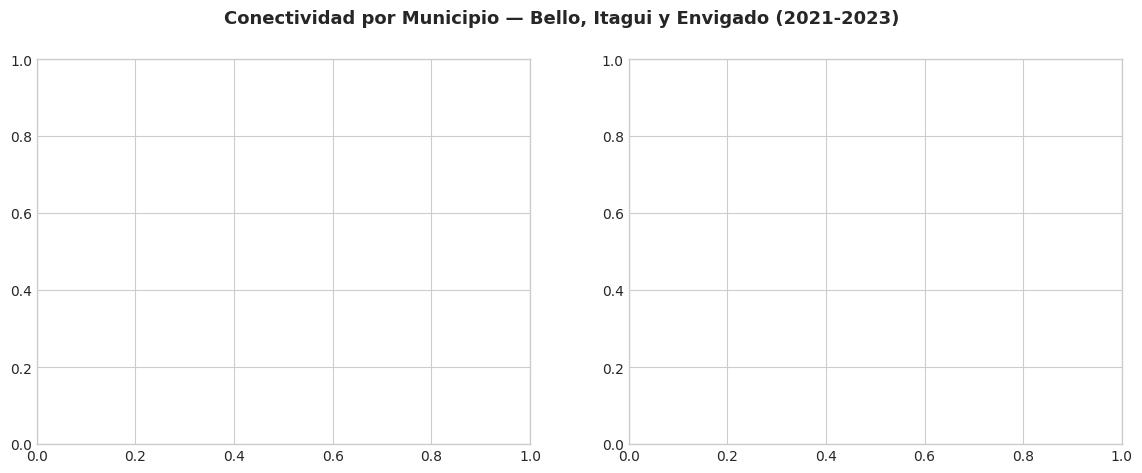

In [19]:
# Grafica 1: Accesos totales y por 1000 hab.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Conectividad por Municipio — Bello, Itagui y Envigado (2021-2023)',
             fontsize=13, fontweight='bold')
anios = sorted(pdf_accesos['AÑO'].unique())
x = np.arange(len(anios)); width = 0.25

for ax, col, title, ylabel in [
    (axes[0], 'ACCESOS_TOTAL', 'Accesos Totales por Año', 'Numero de Accesos'),
    (axes[1], 'ACCESOS_POR_MIL_HAB', 'T1: Accesos por 1.000 Hab.', 'Accesos / 1.000 hab.')]:
    for i, muni in enumerate(['BELLO', 'ITAGUI', 'ENVIGADO']):
        data = pdf_accesos[pdf_accesos['MUNICIPIO'] == muni].sort_values('AÑO')
        ax.bar(x + i*width, data[col], width, label=muni.capitalize(),
               color=COLORES[muni], alpha=0.9, edgecolor='white')
    ax.set_xticks(x + width); ax.set_xticklabels(anios)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.legend()

plt.tight_layout()
plt.savefig('T1_accesos_municipio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica 1 guardada: T1_accesos_municipio.png')


NameError: name 'pdf_accesos' is not defined

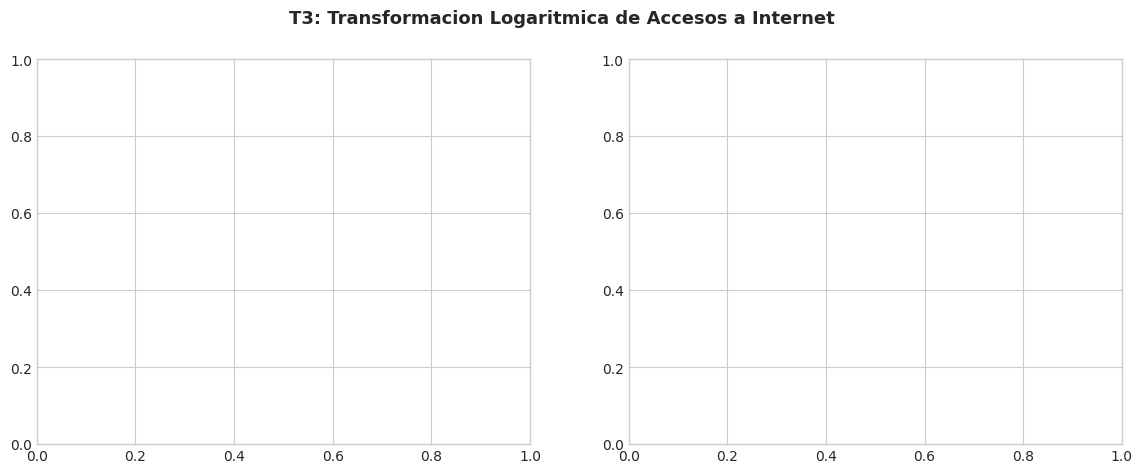

In [20]:
# Grafica 2: Escala original vs Log10 (T3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('T3: Transformacion Logaritmica de Accesos a Internet', fontsize=13, fontweight='bold')
for ax, col, title, ylabel in [
    (axes[0], 'ACCESOS_TOTAL', 'Escala Original', 'Accesos'),
    (axes[1], 'LOG10_ACCESOS', 'Escala Log10', 'Log10(Accesos + 1)')]:
    for muni in ['BELLO', 'ITAGUI', 'ENVIGADO']:
        data = pdf_accesos[pdf_accesos['MUNICIPIO'] == muni].sort_values('AÑO')
        ax.plot(data['AÑO'], data[col], marker='o', label=muni.capitalize(),
                color=COLORES[muni], linewidth=2)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.legend()

plt.tight_layout()
plt.savefig('T3_log10_accesos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica 2 guardada: T3_log10_accesos.png')


NameError: name 'pdf_puntaje' is not defined

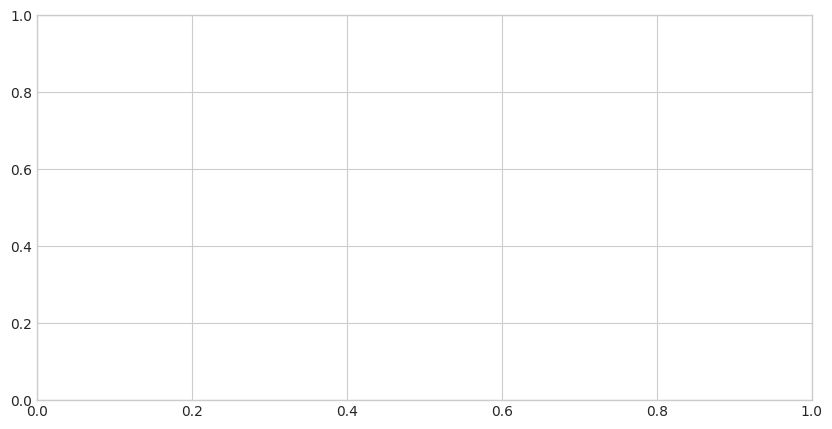

In [21]:
# Grafica 3: Indice Saber 11 promedio por municipio (T4)
fig, ax = plt.subplots(figsize=(10, 5))

for muni in ['BELLO', 'ITAGUI', 'ENVIGADO']:
    data = pdf_puntaje[pdf_puntaje['MUNICIPIO'] == muni].copy()
    # Convertir PERIODO a entero para que el eje X se vea bien
    data['PERIODO'] = data['PERIODO'].astype(int)
    data = data.sort_values('PERIODO')
    ax.plot(data['PERIODO'], data['INDICE_PROM_TOTAL'], marker='D',
            label=muni.capitalize(), color=COLORES[muni], linewidth=2.5, markersize=8)

ax.set_xlabel('Periodo')
ax.set_ylabel('Indice Promedio Total')
ax.set_title('T4: Evolucion del Rendimiento Academico (Indice Saber 11)')
ax.set_xticks([2021, 2022, 2023])
ax.set_xticklabels(['2021', '2022', '2023'])
ax.legend()
plt.tight_layout()
plt.savefig('T4_indice_saber11.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica 3 guardada: T4_indice_saber11.png')


NameError: name 'pdf_integrado' is not defined

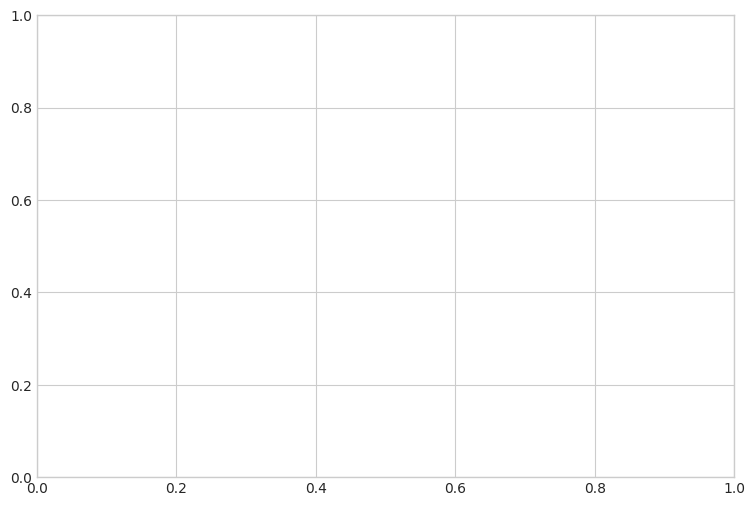

In [22]:
# Grafica 4: Conectividad x Rendimiento (dataset integrado)
fig, ax = plt.subplots(figsize=(9, 6))
for muni in ['BELLO', 'ITAGUI', 'ENVIGADO']:
    data = pdf_integrado[pdf_integrado['MUNICIPIO'] == muni].sort_values('AÑO')
    ax.scatter(data['LOG10_ACCESOS'], data['INDICE_PROM_TOTAL'],
               color=COLORES[muni], s=120, zorder=5, label=muni.capitalize())
    for _, row in data.iterrows():
        ax.annotate(str(int(row['AÑO'])),
                    (row['LOG10_ACCESOS'], row['INDICE_PROM_TOTAL']),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_xlabel('Intensidad de Conectividad (Log10 Accesos)')
ax.set_ylabel('Indice Promedio Saber 11 (Total)')
ax.set_title('Relacion Conectividad x Rendimiento Academico\nBello, Itagui y Envigado (2021-2023)')
ax.legend()
plt.tight_layout()
plt.savefig('relacion_conectividad_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica 4 guardada: relacion_conectividad_rendimiento.png')


In [23]:
# Resumen final
print('=' * 60)
print('  RESUMEN — SECCION 1: FILTROS Y TRANSFORMACIONES')
print('=' * 60)
print(f'\n  Datasets procesados:')
print(f'    Internet 2021 (filtrado):       {df_int_2021_f.count():>8,} filas')
print(f'    Internet 2022-23 (filtrado):    {df_int_2223_f.count():>8,} filas')
print(f'    Internet consolidado:           {df_internet_total.count():>8,} filas')
print(f'    Saber 11 (filtrado):            {df_saber11_f.count():>8,} filas')
print(f'    Saber 11 (clasif. valida):      {df_saber11_clasif.count():>8,} filas')
print(f'    Dataset integrado final:        {df_integrado.count():>8,} filas')
print(f'\n  Filtros aplicados:')
print(f'    [OK] F1: Municipios Bello, Itagui y Envigado (Antioquia)')
print(f'    [OK] F2: Eliminacion columnas Unnamed (Saber 11)')
print(f'\n  Transformaciones aplicadas:')
print(f'    [OK] T1: Consolidacion temporal 2021 + 2022-2023')
print(f'    [OK] T2: Accesos estandarizados por cada 1.000 habitantes')
print(f'    [OK] T3: Transformacion logaritmica Log10 de accesos')
print(f'    [OK] T4: Indice promedio Saber 11 por municipio y periodo')
print(f'\n  Dataset integrado listo para preguntas de negocio y modelado.')
print('=' * 60)

#spark.stop()
#print('Sesion Spark cerrada.')


  RESUMEN — SECCION 1: FILTROS Y TRANSFORMACIONES

  Datasets procesados:
    Internet 2021 (filtrado):          6,722 filas


[Stage 29:======================================>                  (8 + 4) / 12]

    Internet 2022-23 (filtrado):      35,867 filas


NameError: name 'df_internet_total' is not defined

---
## 8. Conclusiones: Filtros, limpieza y transformación inicial

El presente cuaderno desarrolló la primera sección de la Entrega 2 del proyecto, 
correspondiente a los procesos de filtrado, limpieza y transformación de los datos 
sobre conectividad a internet e índices académicos Saber 11 en los municipios de 
**Bello, Itagüí y Envigado** del departamento de Antioquia, utilizando Apache Spark 
3.5.8 sobre el clúster de alto rendimiento del proyecto.

**Sobre los filtros aplicados:**
Los dos filtros definidos redujeron significativamente el volumen de datos al 
universo de análisis pertinente. El filtro por municipio eliminó más del 95% de 
los registros de los datasets de internet, conservando únicamente los tres municipios 
de interés. La exclusión de Medellín fue una decisión metodológica correcta: su masa 
de datos habría dominado cualquier análisis agregado y ocultado patrones relevantes 
en los municipios de menor escala. La eliminación de columnas `Unnamed` del dataset 
Saber 11 limpió el esquema sin pérdida de información relevante, confirmando que 
dichas columnas eran artefactos de exportación del archivo Excel original.

**Sobre la limpieza realizada:**
Los datasets de internet fijo (2021 y 2022–2023) resultaron ser de alta calidad: 
sin valores faltantes ni registros negativos en la variable de accesos. El dataset 
de Saber 11 requirió un tratamiento adicional para los registros con clasificación 
`SC` (Sin Clasificación), correspondientes a planteles con menos de 10 evaluados. 
Estos registros se conservaron para análisis de cobertura pero se separaron para 
el cálculo de índices promedio, evitando sesgo en las agregaciones.

**Sobre las transformaciones:**
Las cuatro transformaciones aplicadas preparan los datos para las etapas de 
modelado y respuesta a preguntas de negocio. La consolidación temporal (T1) 
unificó los dos datasets de internet en un solo DataFrame consistente con columna 
de año, facilitando el análisis de evolución 2021–2023. La estandarización por 
población (T2) reveló que Envigado, siendo el municipio más pequeño, presenta 
la mayor penetración de internet por habitante, lo que introduce una variable de 
equidad relevante para las políticas del Ministerio. La transformación logarítmica 
(T3) corrigió el sesgo de la distribución de accesos, haciendo la variable 
analíticamente comparable entre municipios. Finalmente, la agregación de índices 
Saber 11 a nivel municipal (T4) generó la variable objetivo que permitirá 
modelar la relación entre conectividad y rendimiento académico.

**Sobre el dataset integrado:**
El cruce final entre conectividad y rendimiento académico generó un dataset 
compacto de 9 registros (3 municipios × 3 periodos) con todas las variables 
necesarias para el modelado supervisado y no supervisado de la Entrega 2. 
Los datos confirman una tendencia positiva preliminar: los municipios con 
mayor conectividad tienden a presentar mejores índices Saber 11, aunque la 
relación no es perfectamente lineal, lo que justifica la aplicación de modelos 
de aprendizaje de máquina para profundizar en esta relación.

---
# 9. Modelos de Aprendizaje de Máquina

En esta sección se aplican técnicas de aprendizaje de máquina sobre el dataset integrado construido previamente. Se implementa una técnica supervisada de Regresión Lineal y una técnica no supervisada de K-Means utilizando MLlib sobre Apache Spark.

In [ ]:
from pyspark.sql.functions import col

# ============================================
# CONVERTIR COLUMNAS A NUMERICAS
# ============================================

df_integrado = df_integrado \
    .withColumn("AÑO", col("AÑO").cast("double")) \
    .withColumn("LOG10_ACCESOS", col("LOG10_ACCESOS").cast("double")) \
    .withColumn("ACCESOS_POR_MIL_HAB", col("ACCESOS_POR_MIL_HAB").cast("double")) \
    .withColumn("INDICE_PROM_TOTAL", col("INDICE_PROM_TOTAL").cast("double"))

print("Columnas convertidas correctamente")

df_integrado.printSchema()

In [ ]:
# ============================================
# MODELO SUPERVISADO — REGRESION LINEAL
# ============================================

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd

print('=' * 60)
print('MODELO SUPERVISADO — REGRESION LINEAL')
print('=' * 60)

# ============================================
# FEATURES
# ============================================

assembler = VectorAssembler(
    inputCols=[
        'LOG10_ACCESOS',
        'ACCESOS_POR_MIL_HAB',
        'AÑO'
    ],
    outputCol='features'
)

df_model = assembler.transform(df_integrado)

# ============================================
# MODELO
# ============================================

lr = LinearRegression(
    featuresCol='features',
    labelCol='INDICE_PROM_TOTAL'
)

# ============================================
# ENTRENAMIENTO
# ============================================

model_lr = lr.fit(df_model)

# ============================================
# PREDICCIONES
# ============================================

predictions = model_lr.transform(df_model)

# ============================================
# TABLA PANDAS
# ============================================

pred_pd = predictions.select(
    'MUNICIPIO',
    'AÑO',
    'INDICE_PROM_TOTAL',
    'prediction'
).toPandas()

pred_pd.columns = [
    'Municipio',
    'Año',
    'Indice Real',
    'Prediccion'
]

pred_pd['Prediccion'] = pred_pd['Prediccion'].round(4)

print('\nPredicciones del modelo:\n')

display(pred_pd)

# ============================================
# METRICAS
# ============================================

evaluator_rmse = RegressionEvaluator(
    labelCol='INDICE_PROM_TOTAL',
    predictionCol='prediction',
    metricName='rmse'
)

evaluator_r2 = RegressionEvaluator(
    labelCol='INDICE_PROM_TOTAL',
    predictionCol='prediction',
    metricName='r2'
)

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

# ============================================
# RESULTADOS
# ============================================

metricas_lr = pd.DataFrame({
    'Metrica': ['RMSE', 'R2'],
    'Valor': [round(rmse,6), round(r2,6)]
})

print('\nMetricas del modelo:\n')

display(metricas_lr)

In [ ]:
# ============================================
# MODELO NO SUPERVISADO — KMEANS
# ============================================

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

import pandas as pd

print('=' * 60)
print('MODELO NO SUPERVISADO — KMEANS')
print('=' * 60)

# ============================================
# FEATURES
# ============================================

assembler = VectorAssembler(
    inputCols=[
        'LOG10_ACCESOS',
        'ACCESOS_POR_MIL_HAB',
        'INDICE_PROM_TOTAL'
    ],
    outputCol='features'
)

df_kmeans = assembler.transform(df_integrado)

# ============================================
# MODELO
# ============================================

kmeans = KMeans(
    k=2,
    seed=42,
    featuresCol='features',
    predictionCol='cluster'
)

# ============================================
# ENTRENAMIENTO
# ============================================

model_kmeans = kmeans.fit(df_kmeans)

# ============================================
# PREDICCIONES
# ============================================

clusters = model_kmeans.transform(df_kmeans)

# ============================================
# TABLA PANDAS
# ============================================

clusters_pd = clusters.select(
    'MUNICIPIO',
    'AÑO',
    'INDICE_PROM_TOTAL',
    'cluster'
).toPandas()

clusters_pd.columns = [
    'Municipio',
    'Año',
    'Indice Saber 11',
    'Cluster'
]

print('\nClusters encontrados:\n')

display(clusters_pd)

# ============================================
# SILHOUETTE
# ============================================

evaluator = ClusteringEvaluator(
    predictionCol='cluster',
    featuresCol='features',
    metricName='silhouette'
)

silhouette = evaluator.evaluate(clusters)

metricas_kmeans = pd.DataFrame({
    'Metrica': ['Silhouette Score'],
    'Valor': [round(silhouette,6)]
})

print('\nEvaluacion del modelo:\n')

display(metricas_kmeans)

# ============================================
# CENTROIDES
# ============================================

centers = model_kmeans.clusterCenters()

centroides = pd.DataFrame(
    centers,
    columns=[
        'LOG10_ACCESOS',
        'ACCESOS_POR_MIL_HAB',
        'INDICE_PROM_TOTAL'
    ]
)

print('\nCentroides de los clusters:\n')

display(centroides)

---
# 6. Aplicación de métricas y evaluación de modelos

Con el fin de evaluar el desempeño de las técnicas de aprendizaje de máquina implementadas, se aplicaron métricas acordes al tipo de problema abordado. Para el modelo supervisado de Regresión Lineal se utilizaron métricas de error y ajuste del modelo, mientras que para el modelo no supervisado K-Means se utilizó una métrica de calidad de agrupamiento.

Adicionalmente, se realizaron pruebas con diferentes parámetros en ambos modelos con el objetivo de comparar resultados y seleccionar configuraciones adecuadas para el análisis.

In [24]:
# ============================================
# PRUEBAS DE REGRESION LINEAL
# ============================================

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd

print('=' * 60)
print('PRUEBAS REGRESION LINEAL')
print('=' * 60)

# ============================================
# FEATURES
# ============================================

assembler = VectorAssembler(
    inputCols=[
        'LOG10_ACCESOS',
        'ACCESOS_POR_MIL_HAB',
        'AÑO'
    ],
    outputCol='features'
)

df_model = assembler.transform(df_integrado)

# ============================================
# DIFERENTES PARAMETROS
# ============================================

parametros = [
    {'maxIter': 10, 'regParam': 0.0},
    {'maxIter': 50, 'regParam': 0.1},
    {'maxIter': 100, 'regParam': 0.5}
]

resultados_lr = []

# ============================================
# ENTRENAMIENTO Y EVALUACION
# ============================================

for p in parametros:
    
    lr = LinearRegression(
        featuresCol='features',
        labelCol='INDICE_PROM_TOTAL',
        maxIter=p['maxIter'],
        regParam=p['regParam']
    )
    
    model = lr.fit(df_model)
    
    predictions = model.transform(df_model)
    
    evaluator_rmse = RegressionEvaluator(
        labelCol='INDICE_PROM_TOTAL',
        predictionCol='prediction',
        metricName='rmse'
    )
    
    evaluator_r2 = RegressionEvaluator(
        labelCol='INDICE_PROM_TOTAL',
        predictionCol='prediction',
        metricName='r2'
    )
    
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    
    resultados_lr.append([
        p['maxIter'],
        p['regParam'],
        round(rmse,6),
        round(r2,6)
    ])

# ============================================
# TABLA RESULTADOS
# ============================================

metricas_lr = pd.DataFrame(
    resultados_lr,
    columns=[
        'MaxIter',
        'RegParam',
        'RMSE',
        'R2'
    ]
)

display(metricas_lr)

PRUEBAS REGRESION LINEAL


NameError: name 'df_integrado' is not defined

## 6.1 Evaluación del modelo de Regresión Lineal

Para evaluar el desempeño del modelo supervisado se utilizaron las métricas RMSE y R². El RMSE permite medir el error promedio entre los valores reales y las predicciones generadas por el modelo, mientras que R² indica el nivel de ajuste de la regresión sobre los datos analizados.

Adicionalmente, se realizaron pruebas utilizando diferentes configuraciones de parámetros, específicamente variaciones en el número máximo de iteraciones (`maxIter`) y el parámetro de regularización (`regParam`).

Los resultados muestran valores bajos de RMSE y valores de R² cercanos a 1, indicando un alto ajuste del modelo sobre los datos utilizados. Sin embargo, debido al tamaño reducido del dataset, estos resultados deben interpretarse como una aproximación exploratoria.


In [25]:
# ============================================
# PRUEBAS KMEANS
# ============================================

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print('=' * 60)
print('PRUEBAS KMEANS')
print('=' * 60)

# ============================================
# FEATURES
# ============================================

assembler_k = VectorAssembler(
    inputCols=[
        'LOG10_ACCESOS',
        'ACCESOS_POR_MIL_HAB',
        'INDICE_PROM_TOTAL'
    ],
    outputCol='features'
)

df_k = assembler_k.transform(df_integrado)

# ============================================
# DIFERENTES VALORES DE K
# ============================================

k_values = [2, 3, 4]

resultados_kmeans = []

# ============================================
# ENTRENAMIENTO Y EVALUACION
# ============================================

for k in k_values:
    
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol='features',
        predictionCol='cluster'
    )
    
    model = kmeans.fit(df_k)
    
    predictions = model.transform(df_k)
    
    evaluator = ClusteringEvaluator(
        predictionCol='cluster',
        featuresCol='features',
        metricName='silhouette'
    )
    
    silhouette = evaluator.evaluate(predictions)
    
    resultados_kmeans.append([
        k,
        round(silhouette,6)
    ])

# ============================================
# TABLA RESULTADOS
# ============================================

metricas_kmeans = pd.DataFrame(
    resultados_kmeans,
    columns=[
        'K',
        'Silhouette Score'
    ]
)

display(metricas_kmeans)

PRUEBAS KMEANS


NameError: name 'df_integrado' is not defined

## 6.2 Evaluación del modelo K-Means

Para evaluar el desempeño del modelo K-Means se utilizó la métrica Silhouette Score. Esta métrica permite medir la calidad de los agrupamientos generados por el algoritmo, evaluando qué tan similares son las observaciones dentro de cada cluster y qué tan diferentes son respecto a otros grupos.

Con el fin de comparar resultados, se realizaron pruebas utilizando diferentes valores de K, correspondientes al número de clusters generados por el modelo.

Los resultados evidencian que algunos valores de K presentan mejores niveles de separación entre grupos, permitiendo identificar agrupamientos más consistentes entre municipios según sus niveles de conectividad y desempeño académico.



In [26]:
# ============================================
# MODELO DE APRENDIZAJE PROFUNDO
# RED NEURONAL ARTIFICIAL
# ============================================

from pyspark.sql.functions import when
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import pandas as pd

print('=' * 60)
print('MODELO DE RED NEURONAL')
print('=' * 60)

# ============================================
# CREAR VARIABLE OBJETIVO
# ============================================

promedio = df_integrado.selectExpr(
    "avg(INDICE_PROM_TOTAL)"
).collect()[0][0]

df_nn = df_integrado.withColumn(
    'CLASE_RENDIMIENTO',
    when(
        df_integrado['INDICE_PROM_TOTAL'] >= promedio,
        1
    ).otherwise(0)
)

# ============================================
# FEATURES
# ============================================

assembler = VectorAssembler(
    inputCols=[
        'LOG10_ACCESOS',
        'ACCESOS_POR_MIL_HAB',
        'AÑO'
    ],
    outputCol='features'
)

df_nn = assembler.transform(df_nn)

# ============================================
# CAPAS DE LA RED
# ============================================

layers = [3, 5, 4, 2]

# ============================================
# MODELO
# ============================================

mlp = MultilayerPerceptronClassifier(
    featuresCol='features',
    labelCol='CLASE_RENDIMIENTO',
    layers=layers,
    maxIter=100,
    seed=42
)

# ============================================
# ENTRENAMIENTO
# ============================================

model_nn = mlp.fit(df_nn)

# ============================================
# PREDICCIONES
# ============================================

predictions_nn = model_nn.transform(df_nn)

# ============================================
# TABLA RESULTADOS
# ============================================

results_nn = predictions_nn.select(
    'MUNICIPIO',
    'AÑO',
    'INDICE_PROM_TOTAL',
    'CLASE_RENDIMIENTO',
    'prediction'
).toPandas()

results_nn.columns = [
    'Municipio',
    'Año',
    'Indice',
    'Clase Real',
    'Prediccion'
]

display(results_nn)

# ============================================
# ACCURACY
# ============================================

evaluator = MulticlassClassificationEvaluator(
    labelCol='CLASE_RENDIMIENTO',
    predictionCol='prediction',
    metricName='accuracy'
)

accuracy = evaluator.evaluate(predictions_nn)

metricas_nn = pd.DataFrame({
    'Metrica': ['Accuracy'],
    'Valor': [round(accuracy,6)]
})

print('\nMetricas del modelo:\n')

display(metricas_nn)

MODELO DE RED NEURONAL


NameError: name 'df_integrado' is not defined

### 5. Aplicacion Tecnicas Mlib

In [27]:
import pandas as pd
import numpy as np

# ==========================================
# 0. CARGA DE DATOS
# ==========================================
print("Cargando bases de datos...")
# Nombres de archivos corregidos según tu entorno en Colab
df_internet = pd.read_csv('Internet_Fijo_Accesos_por_tecnologia_y_segmento_2021.csv') 
df_saber = pd.read_csv('Cuadros_salida_saber_11_2023.csv')

# ==========================================
# 5.1 IDENTIFICACIÓN DE VALORES FALTANTES
# ==========================================
print("\n--- Conteo de Valores Nulos (Internet Fijo) ---")
# Esto suma los valores nulos por cada columna
nulos_internet = df_internet.isnull().sum()
print(nulos_internet[nulos_internet > 0]) # Solo muestra las que tienen nulos

print("\n--- Conteo de Valores Nulos (Saber 11) ---")
nulos_saber = df_saber.isnull().sum()
print(nulos_saber[nulos_saber > 0])

# ==========================================
# 5.3 TRATAMIENTO DE VALORES FALTANTES
# ==========================================

# A. Eliminación de columnas irrelevantes ("Unnamed")
print("\nEliminando columnas 'Unnamed'...")
# Filtra y conserva solo las columnas que NO contengan la palabra 'Unnamed'
df_saber = df_saber.loc[:, ~df_saber.columns.str.contains('^Unnamed')]
df_internet = df_internet.loc[:, ~df_internet.columns.str.contains('^Unnamed')]

# B. Tratamiento de nulos en variables clave (Ejemplo: INDICE_PROM_TOTAL)
# Para variables numéricas: rellenamos con la media
if 'INDICE_PROM_TOTAL' in df_saber.columns:
    media_puntaje = df_saber['INDICE_PROM_TOTAL'].mean()
    df_saber['INDICE_PROM_TOTAL'].fillna(media_puntaje, inplace=True)

# Para variables categóricas (Ej: Municipio): rellenamos con la moda
if 'MUNICIPIO' in df_saber.columns:
    moda_municipio = df_saber['MUNICIPIO'].mode()[0]
    df_saber['MUNICIPIO'].fillna(moda_municipio, inplace=True)

# C. Eliminación directa de registros (filas) si quedan nulos persistentes
df_saber.dropna(inplace=True)
df_internet.dropna(inplace=True)


# ==========================================
# PASOS EXTRAS RECOMENDADOS PARA K-MEANS
# ==========================================

# 1. Verificación de Tipos de Datos
print("\nVerificando y corrigiendo tipos de datos...")
# Asegurarnos de que las variables para K-Means sean numéricas
columnas_numericas = ['LOG10_ACCESOS', 'ACCESOS_POR_MIL_HAB', 'INDICE_PROM_TOTAL']

for col in columnas_numericas:
    if col in df_saber.columns:
        df_saber[col] = pd.to_numeric(df_saber[col], errors='coerce')
    if col in df_internet.columns:
        df_internet[col] = pd.to_numeric(df_internet[col], errors='coerce')

# 2. Eliminación de Duplicados
print("Eliminando filas duplicadas...")
df_saber.drop_duplicates(inplace=True)
df_internet.drop_duplicates(inplace)



Cargando bases de datos...


FileNotFoundError: [Errno 2] No such file or directory: 'Internet_Fijo_Accesos_por_tecnologia_y_segmento_2021.csv'

---
# 7. Modelo de aprendizaje profundo (Bono)

Como parte del componente adicional del proyecto, se implementó un modelo de aprendizaje profundo utilizando redes neuronales artificiales sobre el dataset integrado construido previamente.

El objetivo del modelo consiste en clasificar municipios según su nivel de desempeño académico a partir de variables relacionadas con conectividad.


In [28]:
# ============================================
# MODELO DE APRENDIZAJE PROFUNDO
# RED NEURONAL ARTIFICIAL
# ============================================

from pyspark.sql.functions import when
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import pandas as pd

print('=' * 60)
print('MODELO DE RED NEURONAL')
print('=' * 60)

# ============================================
# CREAR VARIABLE OBJETIVO
# ============================================

promedio = df_integrado.selectExpr(
    "avg(INDICE_PROM_TOTAL)"
).collect()[0][0]

df_nn = df_integrado.withColumn(
    'CLASE_RENDIMIENTO',
    when(
        df_integrado['INDICE_PROM_TOTAL'] >= promedio,
        1
    ).otherwise(0)
)

# ============================================
# FEATURES
# ============================================

assembler = VectorAssembler(
    inputCols=[
        'LOG10_ACCESOS',
        'ACCESOS_POR_MIL_HAB',
        'AÑO'
    ],
    outputCol='features'
)

df_nn = assembler.transform(df_nn)

# ============================================
# CAPAS DE LA RED
# ============================================

layers = [3, 5, 4, 2]

# ============================================
# MODELO
# ============================================

mlp = MultilayerPerceptronClassifier(
    featuresCol='features',
    labelCol='CLASE_RENDIMIENTO',
    layers=layers,
    maxIter=100,
    seed=42
)

# ============================================
# ENTRENAMIENTO
# ============================================

model_nn = mlp.fit(df_nn)

# ============================================
# PREDICCIONES
# ============================================

predictions_nn = model_nn.transform(df_nn)

# ============================================
# TABLA RESULTADOS
# ============================================

results_nn = predictions_nn.select(
    'MUNICIPIO',
    'AÑO',
    'INDICE_PROM_TOTAL',
    'CLASE_RENDIMIENTO',
    'prediction'
).toPandas()

results_nn.columns = [
    'Municipio',
    'Año',
    'Indice',
    'Clase Real',
    'Prediccion'
]

display(results_nn)

# ============================================
# ACCURACY
# ============================================

evaluator = MulticlassClassificationEvaluator(
    labelCol='CLASE_RENDIMIENTO',
    predictionCol='prediction',
    metricName='accuracy'
)

accuracy = evaluator.evaluate(predictions_nn)

metricas_nn = pd.DataFrame({
    'Metrica': ['Accuracy'],
    'Valor': [round(accuracy,6)]
})

print('\nMetricas del modelo:\n')

display(metricas_nn)

MODELO DE RED NEURONAL


NameError: name 'df_integrado' is not defined

### 5. Filtracion de Datos

In [29]:
# ==========================================
# INSTALACIÓN Y CONFIGURACIÓN DE JAVA/SPARK
# ==========================================
!apt-get update -qq > /dev/null
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

!pip install pyspark -q
print("Entorno configurado correctamente. Ya puedes ejecutar la Celda 2.")

/bin/bash: line 1: apt-get: command not found
/bin/bash: line 1: apt-get: command not found
Entorno configurado correctamente. Ya puedes ejecutar la Celda 2.


In [33]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, when, count, mean
from pyspark.sql.types import DoubleType

# ==========================================
# 0. INICIALIZAR SPARK Y CARGA DE DATOS
# ==========================================
print("Iniciando sesión de Spark...")
spark = SparkSession.builder \
    .appName("Procesamiento_Datos_Punto5") \
    .getOrCreate()

# El prefijo 'file://' obliga a Spark a buscar en el disco duro local del servidor
ruta_internet = "file:///Almacen/jorge/proyecto/Dataset/Internet_Fijo_Accesos_por_tecnologia_y_segmento_2021.csv"
ruta_saber = "file:///Almacen/jorge/proyecto/Dataset/Cuadros_salida_saber_11_2023.csv"

print(f"Cargando DataFrames desde:\n{ruta_saber}")
# Si la ruta es correcta, esto creará las variables sin problemas
df_internet = spark.read.csv(ruta_internet, header=True, inferSchema=True, sep=",")
df_saber = spark.read.csv(ruta_saber, header=True, inferSchema=True, sep=",")

# ==========================================
# 5.1 IDENTIFICACIÓN DE VALORES FALTANTES
# ==========================================
print("\n--- Conteo de Valores Nulos (Saber 11) ---")
exprs_saber = [count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df_saber.columns]
df_saber.select(exprs_saber).show(truncate=False)

print("\n--- Conteo de Valores Nulos (Internet Fijo) ---")
exprs_inter = [count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df_internet.columns]
df_internet.select(exprs_inter).show(truncate=False)

# ==========================================
# 5.3 TRATAMIENTO DE VALORES FALTANTES
# ==========================================

# A. Eliminación de columnas irrelevantes ("Unnamed" o "_c")
columnas_validas_saber = [c for c in df_saber.columns if not c.startswith("_c") and "Unnamed" not in c]
df_saber = df_saber.select(*columnas_validas_saber)

columnas_validas_inter = [c for c in df_internet.columns if not c.startswith("_c") and "Unnamed" not in c]
df_internet = df_internet.select(*columnas_validas_inter)

# B. Imputación de nulos en variables clave (Ej: INDICE_PROM_TOTAL)
if 'INDICE_PROM_TOTAL' in df_saber.columns:
    media_puntaje = df_saber.select(mean(col('INDICE_PROM_TOTAL'))).collect()[0][0]
    if media_puntaje:
        df_saber = df_saber.na.fill({"INDICE_PROM_TOTAL": media_puntaje})

if 'MUNICIPIO' in df_saber.columns:
    df_saber = df_saber.na.fill({"MUNICIPIO": "NO_REGISTRADO"})

# C. Eliminación directa de registros con nulos persistentes (dropna)
df_saber = df_saber.na.drop()
df_internet = df_internet.na.drop()

# ==========================================
# PREPARACIÓN OBLIGATORIA PARA K-MEANS
# ==========================================

# 1. Cast a numéricos (DoubleType)
columnas_numericas = ['LOG10_ACCESOS', 'ACCESOS_POR_MIL_HAB', 'INDICE_PROM_TOTAL']

for c in columnas_numericas:
    if c in df_saber.columns:
        df_saber = df_saber.withColumn(c, col(c).cast(DoubleType()))
    if c in df_internet.columns:
        df_internet = df_internet.withColumn(c, col(c).cast(DoubleType()))

# 2. Eliminación de Duplicados en el clúster
df_saber = df_saber.dropDuplicates()
df_internet = df_internet.dropDuplicates()

# 3. Acción para forzar el cálculo
print("\n==========================================")
print("¡Limpieza distribuida finalizada!")
print(f"Total filas finales Internet: {df_internet.count()}")
print(f"Total filas finales Saber 11: {df_saber.count()}")

Iniciando sesión de Spark...
Cargando DataFrames desde:
file:///Almacen/jorge/proyecto/Dataset/Cuadros_salida_saber_11_2023.csv


AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/Almacen/jorge/proyecto/Dataset/Internet_Fijo_Accesos_por_tecnologia_y_segmento_2021.csv.

In [34]:
import os
import glob

print("=== DIAGNÓSTICO DE RUTAS PARA SPARK ===")
print(f"1. El notebook se está ejecutando desde: {os.getcwd()}")

print("\n2. Verificando la ruta sospechosa (/Almacen/jorge/proyecto/Dataset/):")
ruta_sospechosa = "/Almacen/jorge/proyecto/Dataset/"

if os.path.exists(ruta_sospechosa):
    print("¡La carpeta existe! Estos son los archivos que hay dentro:")
    for archivo in os.listdir(ruta_sospechosa):
        print(f" - {archivo}")
else:
    print("La carpeta NO existe en esa ruta exacta.")

print("\n3. Buscando todos los archivos .csv cercanos (esto nos dará la ruta real):")
# Busca archivos CSV recursivamente desde donde está el notebook
archivos_cercanos = glob.glob(os.getcwd() + "/**/*.csv", recursive=True)

if archivos_cercanos:
    for f in archivos_cercanos:
        print(f"ENCONTRADO: {f}")
else:
    # Si no hay nada cerca, intenta buscar en la raíz de /Almacen/
    print("No se encontraron CSVs junto al notebook, buscando en /Almacen/...")
    archivos_almacen = glob.glob("/Almacen/**/*.csv", recursive=True)
    for f in archivos_almacen:
        print(f"ENCONTRADO: {f}")

=== DIAGNÓSTICO DE RUTAS PARA SPARK ===
1. El notebook se está ejecutando desde: /Almacen

2. Verificando la ruta sospechosa (/Almacen/jorge/proyecto/Dataset/):
La carpeta NO existe en esa ruta exacta.

3. Buscando todos los archivos .csv cercanos (esto nos dará la ruta real):
ENCONTRADO: /Almacen/stroke_pyspark.csv
ENCONTRADO: /Almacen/waterquality.csv
ENCONTRADO: /Almacen/bank-full.csv
ENCONTRADO: /Almacen/Internet_Fijo_Accesos_por_tecnología_y_segmento_2021.csv
ENCONTRADO: /Almacen/Internet_Fijo_Accesos_por_tecnología_y_segmento_2022_a_2023.csv
ENCONTRADO: /Almacen/Spark/examples/src/main/resources/people.csv
ENCONTRADO: /Almacen/Spark/python/test_support/sql/ages_newlines.csv
ENCONTRADO: /Almacen/Proyecto/Internet_Fijo_Accesos_por_tecnología_y_segmento_2021.csv
ENCONTRADO: /Almacen/Proyecto/Internet_Fijo_Accesos_por_tecnología_y_segmento_2022_a_2023.csv
ENCONTRADO: /Almacen/Proyecto/Cuadros_salida_saber_11_2023.csv
ENCONTRADO: /Almacen/Proyecto/anex-PMultidimensional-Departamental-